# 01. EDA и первичная подготовка данных

В этом ноутбуке выполняется первичный анализ датасета AI4I 2020 Predictive Maintenance Dataset.

Цель анализа:

- проверить размер и структуру датасета;
- изучить типы признаков;
- проверить пропуски и дубликаты;
- изучить распределение целевой переменной;
- проанализировать числовые и категориальные признаки;
- проверить потенциальные признаки утечки данных;
- сделать выводы для дальнейшего моделирования.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH

WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/raw/ai4i2020.csv')

In [3]:
df = pd.read_csv(DATA_PATH)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 14)

## 2. Первичный обзор датасета

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0000,NaN,NaN,NaN,5000.5000,2886.8957,1.0000,2500.7500,5000.5000,7500.2500,10000.0000
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0000,NaN,NaN,NaN,300.0049,2.0003,295.3000,298.3000,300.1000,301.5000,304.5000
Process temperature [K],10000.0000,NaN,NaN,NaN,310.0056,1.4837,305.7000,308.8000,310.1000,311.1000,313.8000
Rotational speed [rpm],10000.0000,NaN,NaN,NaN,1538.7761,179.2841,1168.0000,1423.0000,1503.0000,1612.0000,2886.0000
Torque [Nm],10000.0000,NaN,NaN,NaN,39.9869,9.9689,3.8000,33.2000,40.1000,46.8000,76.6000
Tool wear [min],10000.0000,NaN,NaN,NaN,107.9510,63.6541,0.0000,53.0000,108.0000,162.0000,253.0000
Machine failure,10000.0000,NaN,NaN,NaN,0.0339,0.1810,0.0000,0.0000,0.0000,0.0000,1.0000
TWF,10000.0000,NaN,NaN,NaN,0.0046,0.0677,0.0000,0.0000,0.0000,0.0000,1.0000


In [7]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

## 3. Проверка пропусков

In [8]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [9]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame(
    {
        "missing_count": missing_values,
        "missing_percent": missing_percent,
    }
)

,missing_count,missing_percent
UDI,0,0.0000
Product ID,0,0.0000
Type,0,0.0000
Air temperature [K],0,0.0000
Process temperature [K],0,0.0000
Rotational speed [rpm],0,0.0000
Torque [Nm],0,0.0000
Tool wear [min],0,0.0000
Machine failure,0,0.0000
TWF,0,0.0000


## 4. Проверка дубликатов

In [10]:
duplicates_count = df.duplicated().sum()
duplicates_count

np.int64(0)

## 5. Анализ целевой переменной

Целевая переменная — `Machine failure`.

Это бинарный признак:

- `0` — отказа оборудования не было;
- `1` — произошёл отказ оборудования.

In [11]:
target_counts = df["Machine failure"].value_counts().sort_index()
target_share = df["Machine failure"].value_counts(normalize=True).sort_index()

target_distribution = pd.DataFrame(
    {
        "count": target_counts,
        "share": target_share,
    }
)

target_distribution

,count,share
Machine failure,,
0,9661,0.9661
1,339,0.0339


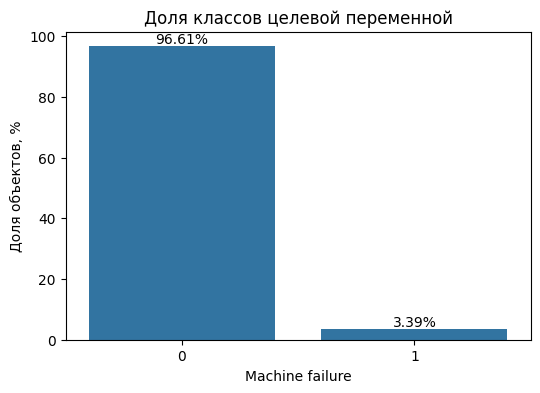

In [14]:
target_distribution_percent = (
    df["Machine failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=target_distribution_percent.index,
    y=target_distribution_percent.values,
)
plt.title("Доля классов целевой переменной")
plt.xlabel("Machine failure")
plt.ylabel("Доля объектов, %")

for i, value in enumerate(target_distribution_percent.values):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

## 6. Служебные признаки и признаки утечки данных

В датасете есть несколько колонок, которые не должны использоваться как признаки основной модели:

- `UDI` — технический идентификатор строки;
- `Product ID` — идентификатор продукта;
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — индикаторы конкретных типов отказа.

Колонки типов отказа могут привести к data leakage, так как они напрямую связаны с фактом отказа оборудования.

In [13]:
id_cols = ["UDI", "Product ID"]
leakage_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
target_col = "Machine failure"

df[id_cols + leakage_cols + [target_col]].head()

,UDI,Product ID,TWF,HDF,PWF,OSF,RNF,Machine failure
0,1,M14860,0,0,0,0,0,0
1,2,L47181,0,0,0,0,0,0
2,3,L47182,0,0,0,0,0,0
3,4,L47183,0,0,0,0,0,0
4,5,L47184,0,0,0,0,0,0


In [15]:
df[leakage_cols + [target_col]].corr()

,TWF,HDF,PWF,OSF,RNF,Machine failure
TWF,1.0000,-0.0073,0.0086,0.0382,0.0310,0.3629
HDF,-0.0073,1.0000,0.0184,0.0464,-0.0047,0.5758
PWF,0.0086,0.0184,1.0000,0.1158,-0.0043,0.5228
OSF,0.0382,0.0464,0.1158,1.0000,-0.0043,0.5311
RNF,0.0310,-0.0047,-0.0043,-0.0043,1.0000,0.0045
Machine failure,0.3629,0.5758,0.5228,0.5311,0.0045,1.0000


Корреляционный анализ показывает, что признаки типов отказов `HDF`, `OSF`, `PWF` и `TWF` заметно связаны с целевой переменной `Machine failure`. Это ожидаемо, так как данные колонки являются индикаторами конкретных причин отказа.

Использование этих признаков в модели привело бы к data leakage: модель получила бы информацию, которая фактически описывает уже произошедший отказ. Поэтому в основной постановке задачи эти колонки исключаются из обучающих признаков.

In [16]:
target_counts = df["Machine failure"].value_counts().sort_index()
target_share = df["Machine failure"].value_counts(normalize=True).sort_index()

target_distribution = pd.DataFrame(
    {
        "count": target_counts,
        "share": target_share,
    }
)

target_distribution

,count,share
Machine failure,,
0,9661,0.9661
1,339,0.0339


## 7. Типы признаков

После исключения идентификаторов, признаков утечки данных и целевой переменной определим, какие признаки будут использоваться в основной модели.

In [19]:
feature_cols = [
    col
    for col in df.columns
    if col not in id_cols + leakage_cols + [target_col]
]

categorical_cols = df[feature_cols].select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_cols = df[feature_cols].select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols, numeric_cols

(['Type'],
 ['Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]'])

В качестве признаков для основной модели остаются один категориальный признак `Type` и пять числовых признаков, описывающих температурный режим, скорость вращения, крутящий момент и износ инструмента.

Идентификаторы и признаки типов отказов исключены из списка обучающих признаков.

## 8. Анализ категориального признака `Type`

Признак `Type` описывает тип продукта. Посмотрим распределение типов и долю отказов внутри каждого типа.

In [20]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [21]:
df["Type"].value_counts(normalize=True)

Type
L   0.6000
M   0.2997
H   0.1003
Name: proportion, dtype: float64

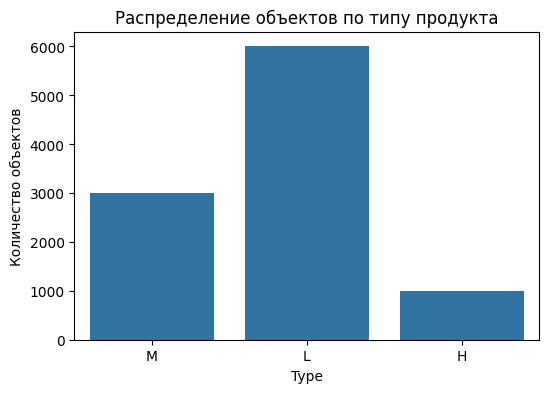

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Type")
plt.title("Распределение объектов по типу продукта")
plt.xlabel("Type")
plt.ylabel("Количество объектов")
plt.show()

In [23]:
type_target_table = pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index",
)

type_target_table

Machine failure,0,1
Type,,
H,0.9791,0.0209
L,0.9608,0.0392
M,0.9723,0.0277


## 9. Анализ числовых признаков

Рассмотрим распределения числовых признаков, которые описывают режим работы оборудования.

In [26]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0000,300.0049,2.0003,295.3000,298.3000,300.1000,301.5000,304.5000
Process temperature [K],10000.0000,310.0056,1.4837,305.7000,308.8000,310.1000,311.1000,313.8000
Rotational speed [rpm],10000.0000,1538.7761,179.2841,1168.0000,1423.0000,1503.0000,1612.0000,2886.0000
Torque [Nm],10000.0000,39.9869,9.9689,3.8000,33.2000,40.1000,46.8000,76.6000
Tool wear [min],10000.0000,107.9510,63.6541,0.0000,53.0000,108.0000,162.0000,253.0000


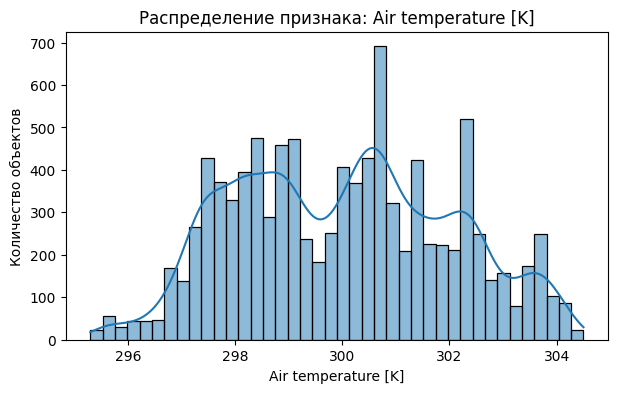

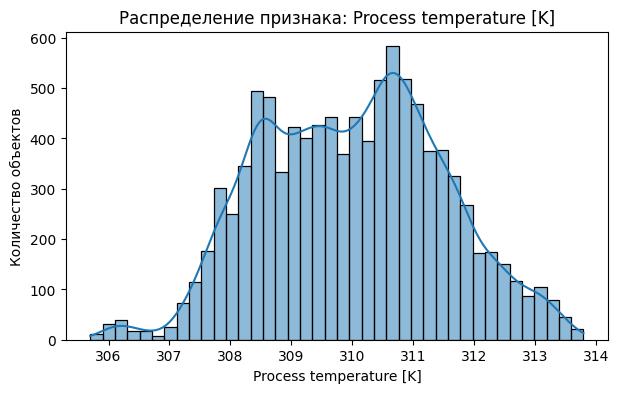

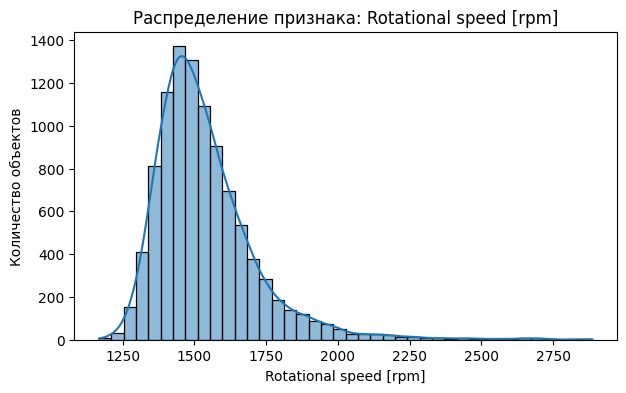

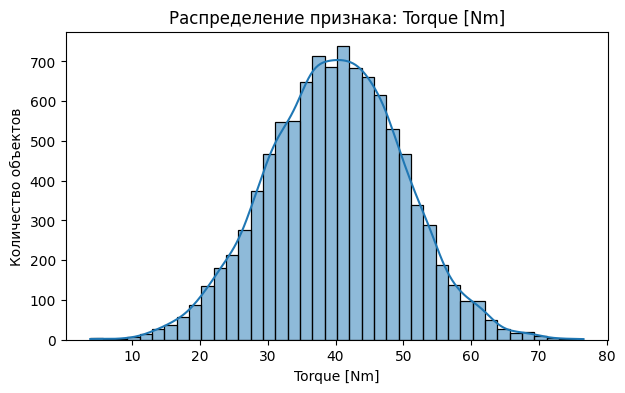

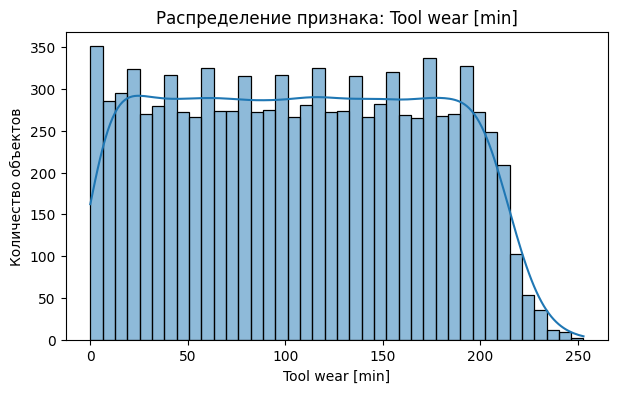

In [27]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, bins=40, kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество объектов")
    plt.show()

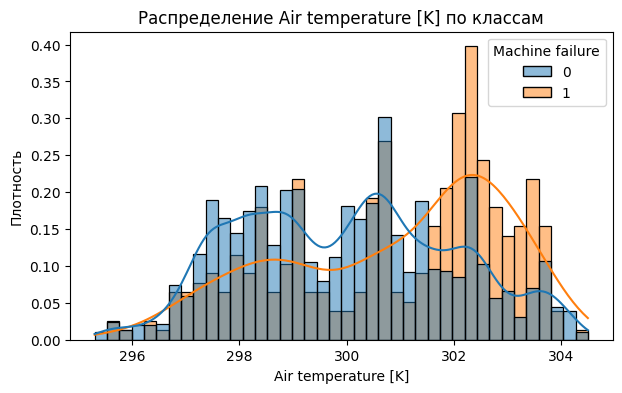

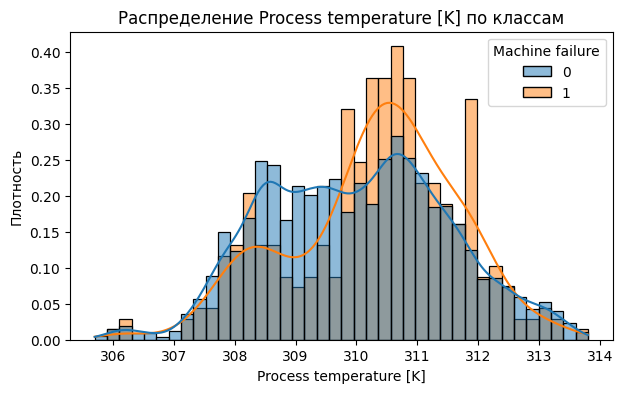

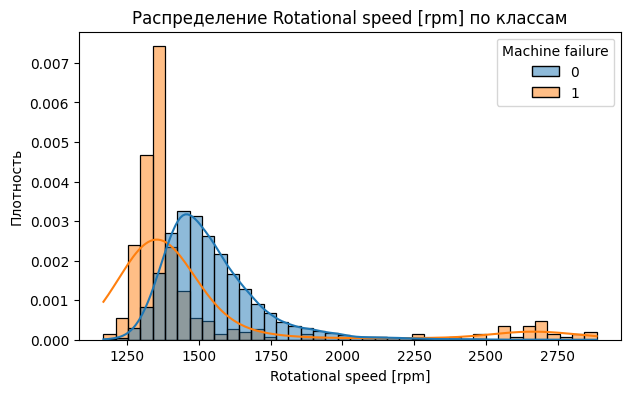

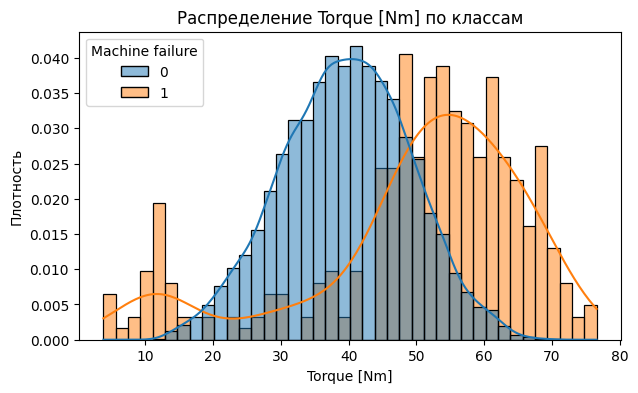

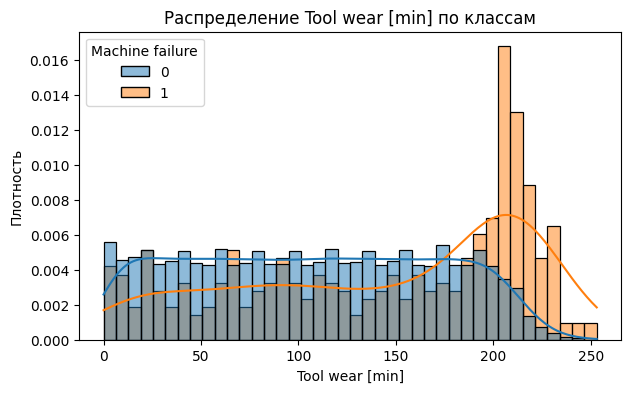

In [28]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df,
        x=col,
        hue="Machine failure",
        bins=40,
        kde=True,
        stat="density",
        common_norm=False,
    )
    plt.title(f"Распределение {col} по классам")
    plt.xlabel(col)
    plt.ylabel("Плотность")
    plt.show()

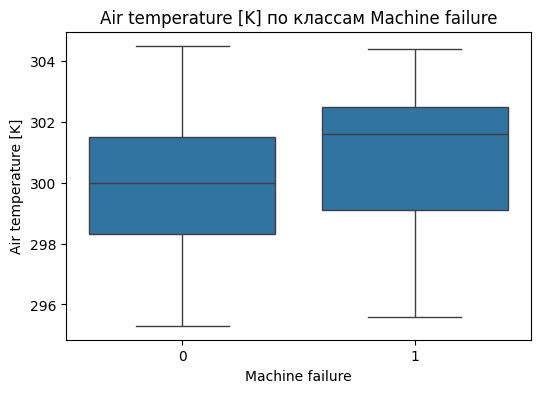

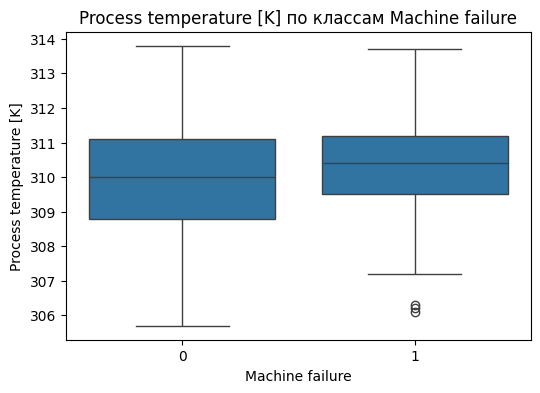

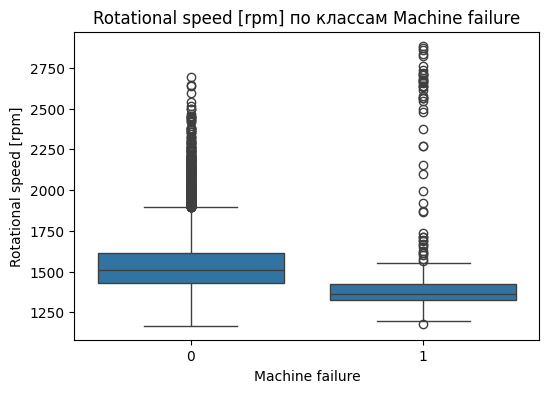

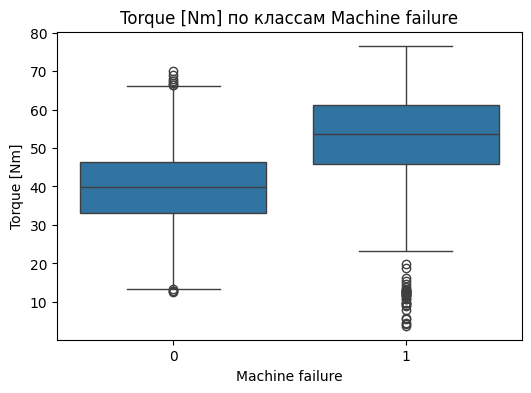

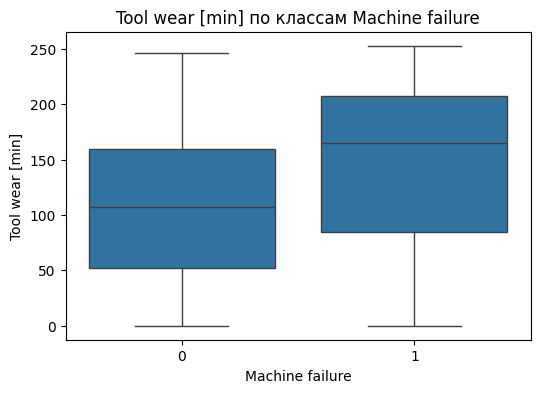

In [29]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Machine failure", y=col)
    plt.title(f"{col} по классам Machine failure")
    plt.xlabel("Machine failure")
    plt.ylabel(col)
    plt.show()

Числовые признаки имеют разные масштабы измерения: температуры измеряются в K, скорость вращения — в rpm, крутящий момент — в Nm, износ инструмента — в минутах. Поэтому для линейных моделей потребуется масштабирование признаков.

По распределениям видно, что классы `Machine failure = 0` и `Machine failure = 1` отличаются по нескольким признакам:

- у объектов с отказом чаще наблюдается более высокая `Air temperature [K]`;
- `Torque [Nm]` у отказавших машин в среднем выше, чем у объектов без отказа;
- `Rotational speed [rpm]` у объектов с отказом чаще ниже, но также встречаются отдельные очень высокие значения;
- `Tool wear [min]` у отказавших машин в среднем выше;
- `Process temperature [K]` также имеет различия между классами, но они выражены слабее.

Эти различия показывают, что числовые признаки содержат полезный сигнал для предсказания отказа оборудования.

## 10. Корреляционный анализ

Построим корреляционную матрицу для числовых признаков и целевой переменной. Идентификаторы и признаки типов отказов не учитываются, так как они не будут использоваться при обучении основной модели.

In [30]:
corr_cols = numeric_cols + [target_col]

corr_matrix = df[corr_cols].corr()
corr_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.0000,0.8761,0.0227,-0.0138,0.0139,0.0826
Process temperature [K],0.8761,1.0000,0.0193,-0.0141,0.0135,0.0359
Rotational speed [rpm],0.0227,0.0193,1.0000,-0.8750,0.0002,-0.0442
Torque [Nm],-0.0138,-0.0141,-0.8750,1.0000,-0.0031,0.1913
Tool wear [min],0.0139,0.0135,0.0002,-0.0031,1.0000,0.1054
Machine failure,0.0826,0.0359,-0.0442,0.1913,0.1054,1.0000


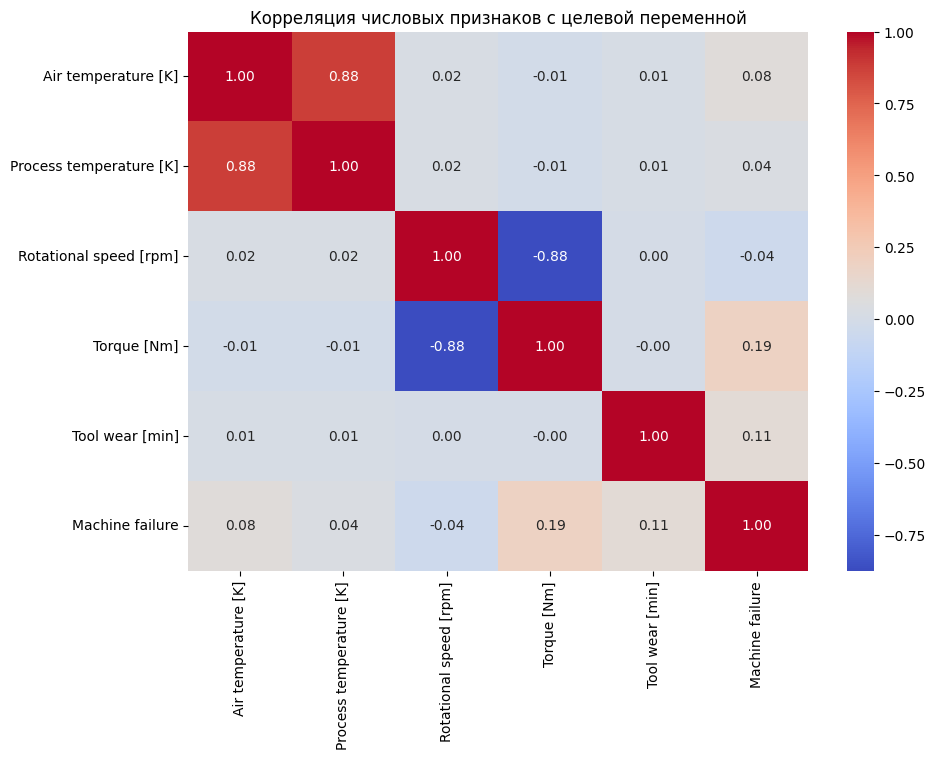

In [31]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Корреляция числовых признаков с целевой переменной")
plt.show()

Корреляционный анализ показывает несколько важных зависимостей:

- `Air temperature [K]` и `Process temperature [K]` сильно положительно коррелируют между собой;
- `Rotational speed [rpm]` и `Torque [Nm]` имеют сильную отрицательную корреляцию;
- среди исходных числовых признаков наиболее заметная положительная связь с целевой переменной наблюдается у `Torque [Nm]` и `Tool wear [min]`;
- при этом корреляции отдельных признаков с `Machine failure` остаются невысокими.

Это означает, что задача не сводится к одному простому признаку. Для моделирования имеет смысл использовать комбинацию признаков, feature engineering и нелинейные модели.

## 11. Проверка выбросов

Для первичной оценки выбросов используем межквартильный размах IQR. В этой задаче экстремальные значения не будем автоматически удалять, так как они могут быть важными сигналами неисправности оборудования.

In [32]:
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_share = outliers_count / len(df)

    outlier_summary.append(
        {
            "feature": col,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers_count": outliers_count,
            "outliers_share": outliers_share,
        }
    )

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,feature,lower_bound,upper_bound,outliers_count,outliers_share
0,Air temperature [K],293.5000,306.3000,0,0.0000
1,Process temperature [K],305.3500,314.5500,0,0.0000
2,Rotational speed [rpm],1139.5000,1895.5000,418,0.0418
3,Torque [Nm],12.8000,67.2000,69,0.0069
4,Tool wear [min],-110.5000,325.5000,0,0.0000


По методу IQR выбросы обнаружены у признаков `Rotational speed [rpm]` и `Torque [Nm]`. У `Rotational speed [rpm]` доля выбросов составляет около 4.18%, у `Torque [Nm]` — около 0.69%.

Эти значения не удаляются автоматически, так как в задаче предиктивного обслуживания оборудования экстремальные значения скорости вращения или крутящего момента могут быть связаны с риском отказа. Удаление таких наблюдений могло бы привести к потере полезного сигнала для модели.

## 12. Feature engineering

Создадим несколько новых признаков на основе физических параметров оборудования.

In [33]:
sys.path.append(str(PROJECT_ROOT))

from src.features import add_features

In [34]:
df_fe = add_features(df)

new_features = [
    "temperature_diff",
    "power_proxy",
    "torque_per_rpm",
    "wear_torque_interaction",
]

df_fe[new_features].head()

,temperature_diff,power_proxy,torque_per_rpm,wear_torque_interaction
0,10.5000,66382.8000,0.0276,0.0000
1,10.5000,65190.4000,0.0329,138.9000
2,10.4000,74001.2000,0.0330,247.0000
3,10.4000,56603.5000,0.0276,276.5000
4,10.5000,56320.0000,0.0284,360.0000


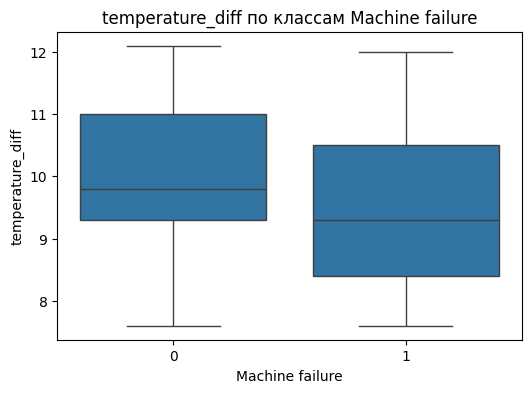

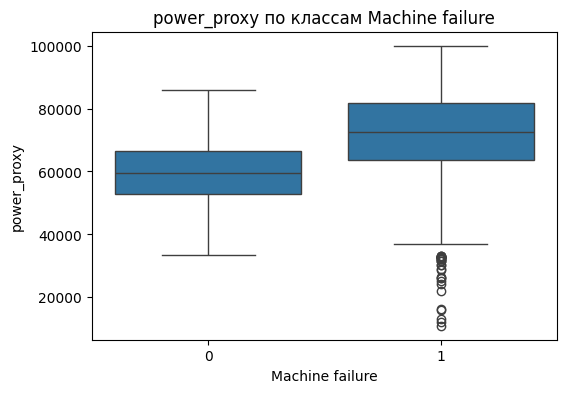

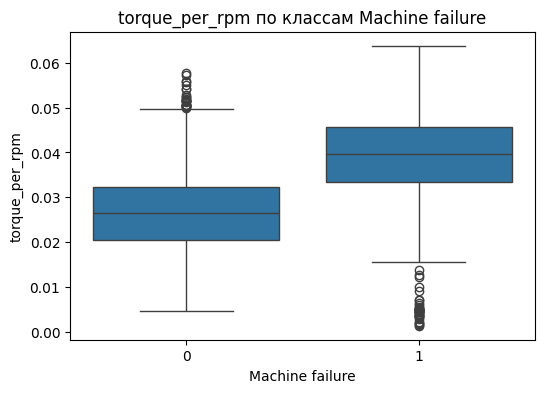

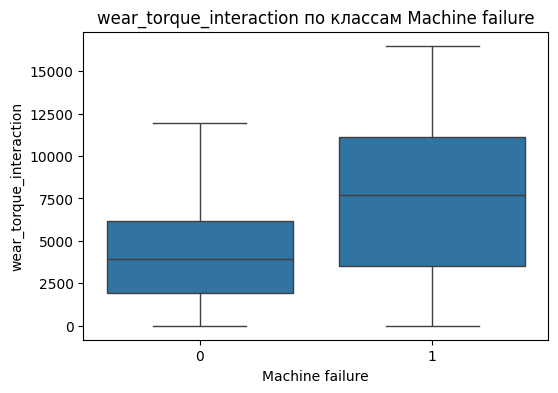

In [35]:
for col in new_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_fe, x="Machine failure", y=col)
    plt.title(f"{col} по классам Machine failure")
    plt.xlabel("Machine failure")
    plt.ylabel(col)
    plt.show()

Новые признаки показывают различия между классами `Machine failure = 0` и `Machine failure = 1`.

Наиболее заметные различия видны у признаков:

- `power_proxy` — у отказавших машин значения в среднем выше;
- `torque_per_rpm` — у объектов с отказом значения чаще выше;
- `wear_torque_interaction` — у отказавших машин значения заметно выше.

Это соответствует предметной логике: высокая нагрузка, высокий крутящий момент относительно скорости вращения и сочетание износа инструмента с нагрузкой могут быть связаны с повышенным риском отказа оборудования.

Эти признаки будут использованы в экспериментах после baseline-модели.

## 13. Проверка train/validation/test split

Для дальнейшего моделирования данные будут разделены на train/validation/test в пропорции 70/15/15 со стратификацией по целевой переменной.

In [36]:
from src.preprocessing import split_features_target, make_train_val_test_split

In [37]:
X, y = split_features_target(df_fe)

X_train, X_val, X_test, y_train, y_val, y_test = make_train_val_test_split(X, y)

X_train.shape, X_val.shape, X_test.shape

((7000, 10), (1500, 10), (1500, 10))

In [38]:
split_distribution = pd.DataFrame(
    {
        "train": y_train.value_counts(normalize=True).sort_index(),
        "validation": y_val.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    }
)

split_distribution

,train,validation,test
Machine failure,,,
0,0.9661,0.9660,0.9660
1,0.0339,0.0340,0.0340


In [39]:
split_counts = pd.DataFrame(
    {
        "train": y_train.value_counts().sort_index(),
        "validation": y_val.value_counts().sort_index(),
        "test": y_test.value_counts().sort_index(),
    }
)

split_counts

,train,validation,test
Machine failure,,,
0,6763,1449,1449
1,237,51,51


## 14. Выводы по EDA

В рамках первичного анализа данных были получены следующие выводы:

- датасет содержит 10 000 строк и 14 колонок;
- целевая переменная `Machine failure` является бинарной;
- задача является несбалансированной классификацией: отказ оборудования встречается только в 3.39% наблюдений;
- пропуски в данных отсутствуют;
- полные дубликаты строк отсутствуют;
- `UDI` и `Product ID` являются идентификаторами и не будут использоваться при обучении моделей;
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` являются индикаторами типов отказов и не будут использоваться в основной модели из-за риска data leakage;
- числовые признаки имеют разные масштабы, поэтому для линейных моделей потребуется масштабирование;
- по EDA видно, что признаки `Torque [Nm]`, `Tool wear [min]`, `Rotational speed [rpm]` и некоторые новые признаки различаются между классами;
- для дальнейшего моделирования выбраны метрики PR-AUC, F1-score, Recall, Precision и ROC-AUC;
- данные разделены на train/validation/test в пропорции 70/15/15 со стратификацией по целевой переменной;
- для экспериментов будут использованы как исходные признаки, так и новые признаки, созданные на этапе feature engineering.